In [2]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()
print("SHAPE")
print(df.shape)
print()

print("HEAD ")
display(df.head())
print()

print("INFO")
df.info()

SHAPE
(891, 12)

HEAD 


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [33]:

print(" EKSİK DEĞERLER(NaN)")
print(df.isnull().sum())

print("EKSİK VERİ ORANLARI (%)")
print(df.isnull().mean()*100)

medyan_yas = df["Age"].median()
df["Age"] = df["Age"].fillna(medyan_yas)

 EKSİK DEĞERLER(NaN)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
EKSİK VERİ ORANLARI (%)
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


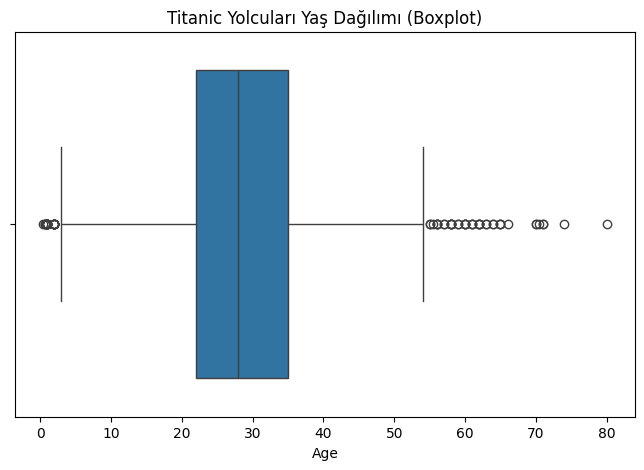

Toplam Yolcu Sayısı: 891


In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Age"])
plt.title("Titanic Yolcuları Yaş Dağılımı (Boxplot)")
plt.show()
print("Toplam Yolcu Sayısı:", df.shape[0])

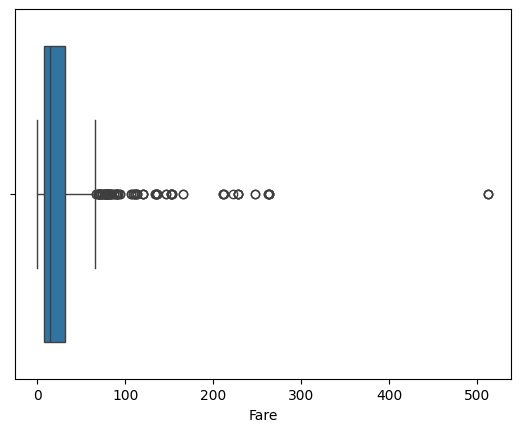

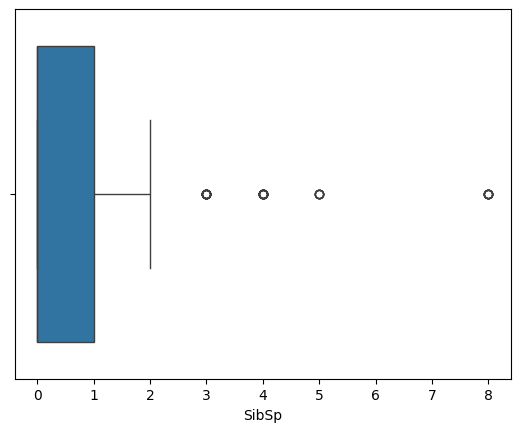

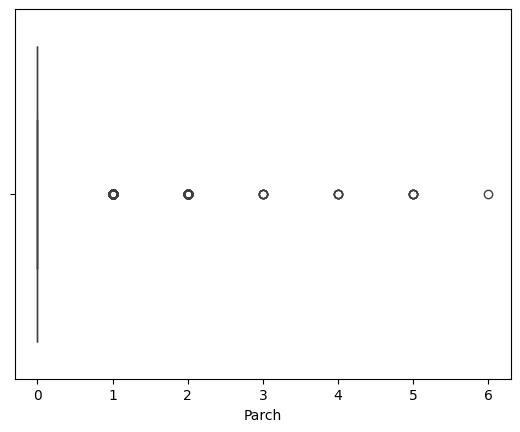

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Alt Sınır: -26.724
Üst Sınır: 65.6344
Aykırı değer (outlier) içeren yolcu sayısı: 116
Hatalı/imkansız veriler silindi. Güncel satır sayısı: 876
0 ve 1 dışındaki hatalı satır sayısı: 0
1, 2, 3 dışındaki hatalı/anormal Pclass satır sayısı: 0
Güncel satır sayısı: 876


In [35]:


sns.boxplot(x=df["Fare"])
plt.show()

sns.boxplot(x=df['SibSp'])
plt.show()

sns.boxplot(x=df["Parch"])
plt.show()

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Alt Sınır: {alt_sinir}")
print(f"Üst Sınır: {ust_sinir}")


outliers = df[(df["Fare"] < alt_sinir) | (df["Fare"] > ust_sinir)]

print(f"Aykırı değer (outlier) içeren yolcu sayısı: {outliers.shape[0]}")

# 1. İmkansız/hatalı koşulu sağlayan satırların indekslerini buluyoruz
hatali_indeksler = df[df["Fare"] <= 0].index

# 2. .drop() kullanarak bu hatalı satırları veri setinden siliyoruz
df = df.drop(index=hatali_indeksler)

print(f"Hatalı/imkansız veriler silindi. Güncel satır sayısı: {df.shape[0]}")

# 1. Survived sütununda 0 ve 1 DIŞINDA bir değer var mı diye kontrol edelim
hatali_survived = df[~df["Survived"].isin([0, 1])]
print(f"0 ve 1 dışındaki hatalı satır sayısı: {hatali_survived.shape[0]}")

# 1. Pclass sütununda 1, 2 ve 3 DIŞINDA bir değer var mı bakalım
hatali_pclass = df[~df["Pclass"].isin([1, 2, 3])]
print(f"1, 2, 3 dışındaki hatalı/anormal Pclass satır sayısı: {hatali_pclass.shape[0]}")

# 2. Eğer varsa, bu hatalı değerleri veri setinden SİLİYORUZ (drop ediyoruz)
df = df[df["Pclass"].isin([1, 2, 3])]

print(f"Güncel satır sayısı: {df.shape[0]}")



--- SAYISAL SÜTUNLARIN DAĞILIMI ---


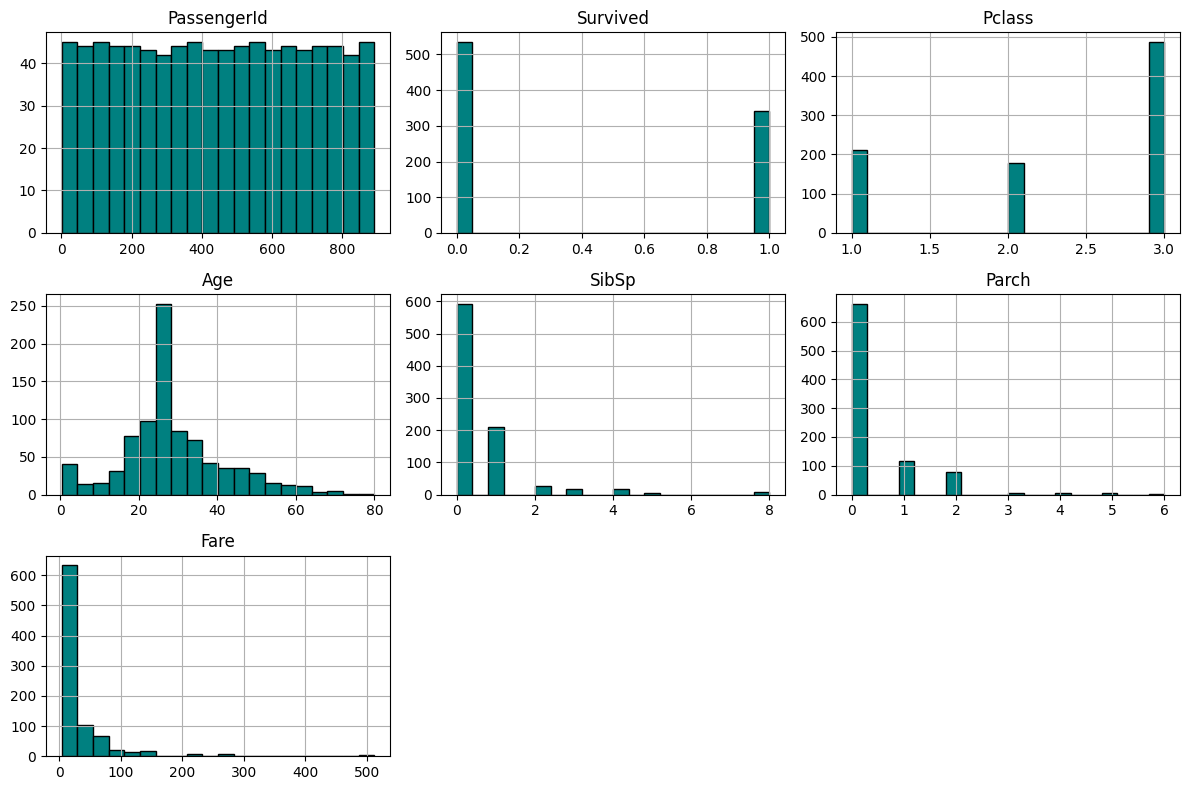


--- Sex Sütununun Dağılımı (Frekansı) ---
Sex
male      562
female    314
Name: count, dtype: int64


/tmp/ipykernel_4468/105831369.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")


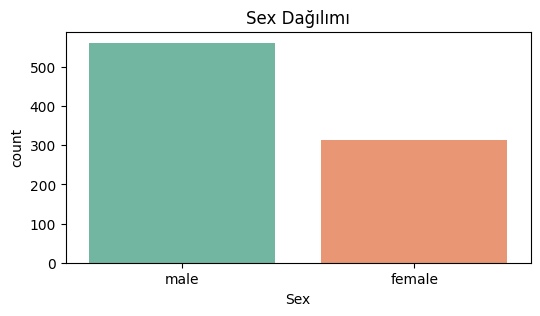


--- Embarked Sütununun Dağılımı (Frekansı) ---
Embarked
S    629
C    168
Q     77
Name: count, dtype: int64


/tmp/ipykernel_4468/105831369.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")


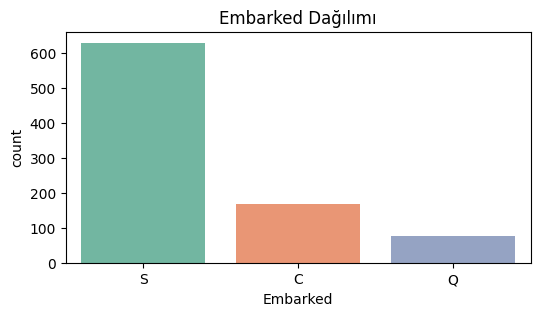


--- Pclass Sütununun Dağılımı (Frekansı) ---
Pclass
3    487
1    211
2    178
Name: count, dtype: int64


/tmp/ipykernel_4468/105831369.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")


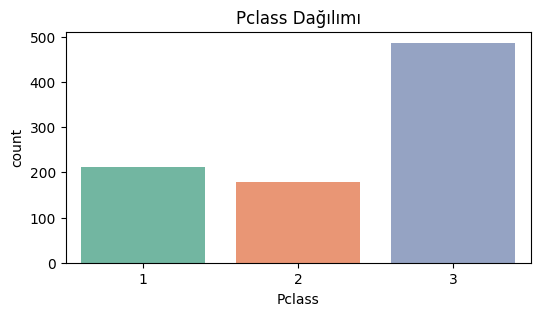


--- Survived Sütununun Dağılımı (Frekansı) ---
Survived
0    535
1    341
Name: count, dtype: int64


/tmp/ipykernel_4468/105831369.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")


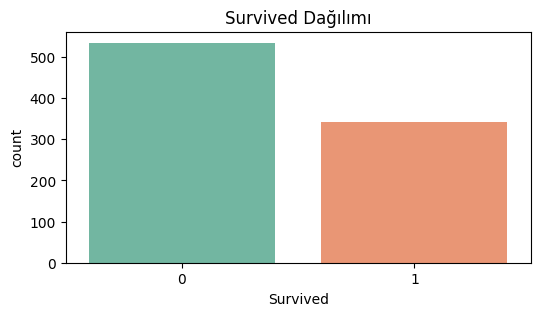

--- Bilet Sınıfına (Pclass) Göre Hayatta Kalma Oranları ---
Pclass
1    0.644550
2    0.488764
3    0.242300
Name: Survived, dtype: float64
PassengerId    876
Survived       876
Pclass         876
Name           876
Sex            876
Age            876
SibSp          876
Parch          876
Ticket         876
Fare           876
Cabin          201
Embarked       874
dtype: int64
Sex sütunu başarıyla düzeltildi:
Sex
male      562
female    314
Name: count, dtype: int64
--- Cinsiyete Göre Hayatta Kalma Oranları ---
Sex
female    0.742038
male      0.192171
Name: Survived, dtype: float64


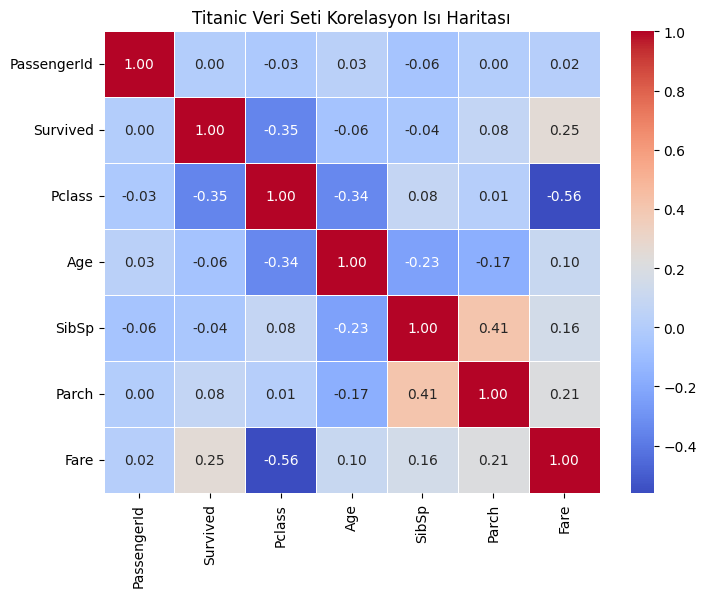

--- Cinsiyet ve Sınıf Kırılımlı Hayatta Kalma Oranları (Pivot Tablo) ---
Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.384615  0.166667  0.134111


In [36]:


print("--- SAYISAL SÜTUNLARIN DAĞILIMI ---")
df.hist(bins=20, figsize=(12, 8), color="teal", edgecolor="black")
plt.tight_layout()  #grafiklerin birbirine girmesini engeller
plt.show()


kategorik_sutunlar = ["Sex", "Embarked", "Pclass", "Survived"]

for col in kategorik_sutunlar:
    if col in df.columns: #if col in df.columns: satırı ise bir güvenlik önlemidir; "Acaba bu sütun bizim veri setimizde gerçekten var mı?" diye kontrol eder, yoksa hata verip kodun çökmesini engeller
        print(f"\n--- {col} Sütununun Dağılımı (Frekansı) ---")
        print(df[col].value_counts())

        # Bar plot ile görselleştirme
        plt.figure(figsize=(6, 3))
        sns.countplot(x=df[col], palette="Set2")
        plt.title(f"{col} Dağılımı")
        plt.show()

# Bilet sınıfına (Pclass) göre ortalama hayatta kalma oranını hesaplıyoruz
pclass_orani = df.groupby("Pclass")["Survived"].mean()

print("--- Bilet Sınıfına (Pclass) Göre Hayatta Kalma Oranları ---")
print(pclass_orani)

print(df.notnull().sum())


# Orijinal dosyadan Sex sütununu doğru dosya adıyla geri yüklüyoruz
df_orijinal = pd.read_csv("Titanic-Dataset.csv")

# Bozulan Sex sütununu orijinaliyle değiştiriyoruz
df["Sex"] = df_orijinal["Sex"]

# Kontrol edelim
print("Sex sütunu başarıyla düzeltildi:")
print(df["Sex"].value_counts(dropna=False))

# Cinsiyete göre ortalama hayatta kalma oranını hesaplıyoruz
cinsiyet_orani = df.groupby("Sex")["Survived"].mean()

print("--- Cinsiyete Göre Hayatta Kalma Oranları ---")
print(cinsiyet_orani)

# 1. Sayısal sütunlar arasındaki korelasyon matrisini hesaplıyoruz
korelasyon = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(korelasyon, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Titanic Veri Seti Korelasyon Isı Haritası")
plt.show()

# Sex ve Pclass kırılımında ortalama hayatta kalma oranını pivot tablo ile çıkarıyoruz
pivot_titanic = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')

print("--- Cinsiyet ve Sınıf Kırılımlı Hayatta Kalma Oranları (Pivot Tablo) ---")
print(pivot_titanic)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 876 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  876 non-null    int64  
 1   Survived     876 non-null    int64  
 2   Pclass       876 non-null    int64  
 3   Name         876 non-null    object 
 4   Sex          876 non-null    object 
 5   Age          876 non-null    float64
 6   SibSp        876 non-null    int64  
 7   Parch        876 non-null    int64  
 8   Ticket       876 non-null    object 
 9   Fare         876 non-null    float64
 10  Cabin        201 non-null    object 
 11  Sex_Encoded  876 non-null    int64  
 12  Embarked_Q   876 non-null    bool   
 13  Embarked_S   876 non-null    bool   
dtypes: bool(2), float64(2), int64(6), object(4)
memory usage: 90.7+ KB


In [49]:
import pandas as pd

# 1. Aile büyüklüğüne göre tek başına seyahat etme durumu
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# 2. Name sütunundan unvanları (Title) çekme ve sadeleştirme
if 'Name' in df.columns:
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

    # Nadir unvanları tek bir çatı altında toplama
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col',
        'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

    # Kısaltmaları düzeltme
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 3. One-Hot Encoding ile Title sütununu sayısal formata çevirme
if 'Title' in df.columns and df['Title'].dtype == 'object':
    df = pd.get_dummies(df, columns=['Title'], drop_first=True, dtype=int)

# 4. Model için gereksiz ve çok eksik verili sütunları güvenle düşürme
sutunlari_dusur = ['PassengerId', 'Ticket', 'Name', 'Sex', 'Cabin']

# Veri setinde gerçekten var olanları güvenle sil (hata vermez)
df = df.drop(columns=[col for col in sutunlari_dusur if col in df.columns])

print("--- Temizlik ve Dönüştürme İşlemleri Başarıyla Tamamlandı! ---")
print(df.columns)

--- Temizlik ve Dönüştürme İşlemleri Başarıyla Tamamlandı! ---
Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_Encoded',
       'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare'],
      dtype='object')


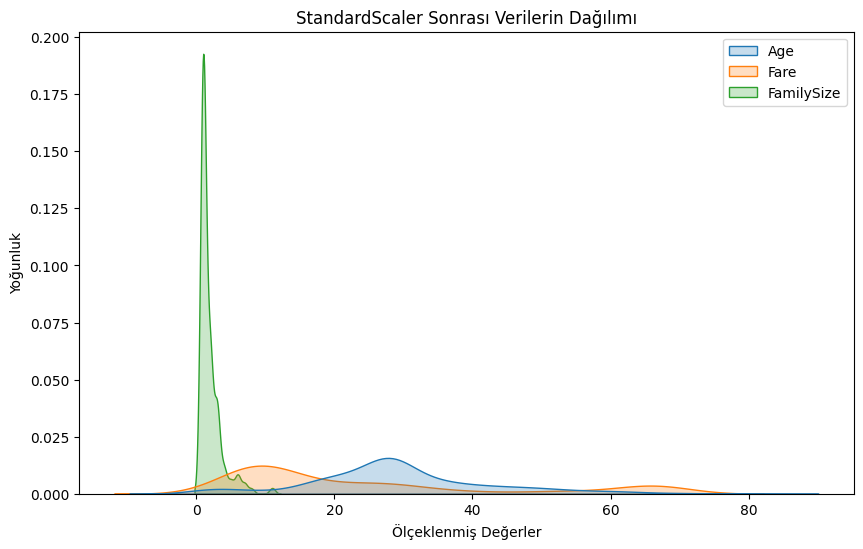

In [50]:
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[['Age', 'Fare', 'FamilySize']], fill=True)
plt.title("StandardScaler Sonrası Verilerin Dağılımı")
plt.xlabel("Ölçeklenmiş Değerler")
plt.ylabel("Yoğunluk")
plt.show()



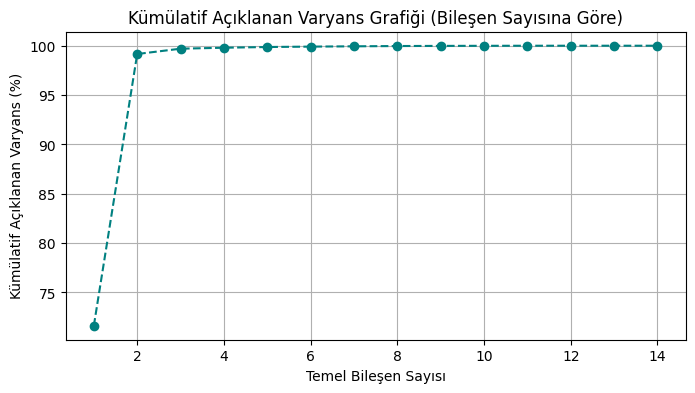

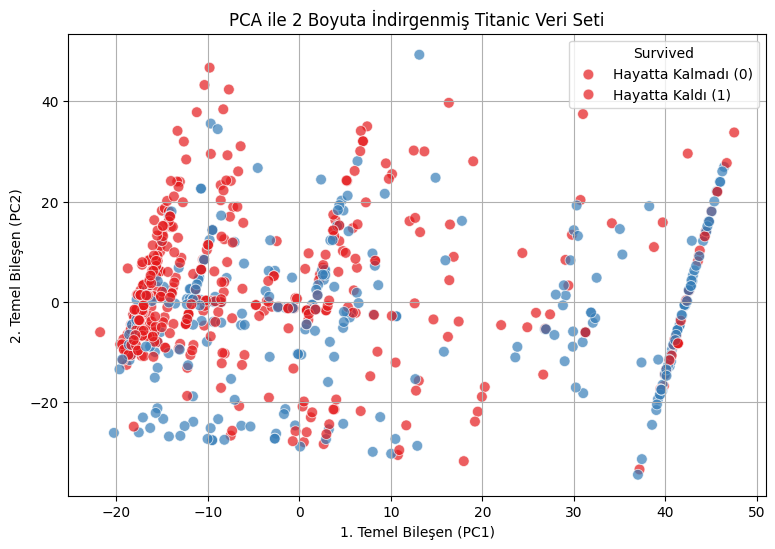

In [51]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Sadece sayısal sütunları seçip X matrisini oluşturalım
X = df.select_dtypes(include=['number']).copy()

if 'Survived' in X.columns:
    X = X.drop(columns=['Survived'])

# 2. Tüm olası bileşenler üzerinden PCA çalıştıralım
pca_full = PCA()
pca_full.fit(X)

# --- Grafik 1: Explained Variance (Kümülatif Açıklanan Varyans) Oranı ---
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         pca_full.explained_variance_ratio_.cumsum() * 100,
         marker='o', linestyle='--', color='teal')
plt.title("Kümülatif Açıklanan Varyans Grafiği (Bileşen Sayısına Göre)")
plt.xlabel("Temel Bileşen Sayısı")
plt.ylabel("Kümülatif Açıklanan Varyans (%)")
plt.grid(True)
plt.show()

# 3. Veriyi İlk 2 Bileşene (2D) İndirgeme
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)

# Sonuçları geçici bir DataFrame'e aktaralım
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Survived'] = df['Survived'].values

# --- Grafik 2: İlk 2 Bileşene Göre Dağılım (Survived Renklendirmeli) ---
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Survived',
    data=df_pca,
    palette='Set1',
    alpha=0.7,
    s=60
)
plt.title("PCA ile 2 Boyuta İndirgenmiş Titanic Veri Seti")
plt.xlabel("1. Temel Bileşen (PC1)")
plt.ylabel("2. Temel Bileşen (PC2)")
plt.legend(title="Survived", labels=['Hayatta Kalmadı (0)', 'Hayatta Kaldı (1)'])
plt.grid(True)
plt.show()


In [52]:
from sklearn.model_selection import train_test_split

if 'Sex' in df.columns and df['Sex'].dtype == 'object':
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 2. Hedef sütunu (y) ve girdi özelliklerini (X) ayıralım
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("Eğitim (Train) seti boyutu (%70):", X_train.shape)
print("Test seti boyutu (%30):", X_test.shape)

Eğitim (Train) seti boyutu (%70): (613, 14)
Test seti boyutu (%30): (263, 14)


In [41]:
# y_train içindeki sınıfların dağılımına bakalım (Örn: 0 ve 1 sayısı)
print(y_train.value_counts(normalize=True) * 100)


Survived
0    60.195759
1    39.804241
Name: proportion, dtype: float64


In [53]:
# X_train içindeki sütunların tiplerini kontrol edelim
print(X_train.dtypes)

Pclass           int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Sex_Encoded      int64
Embarked_Q       int64
Embarked_S       int64
FamilySize       int64
IsAlone          int64
Title_Miss       int64
Title_Mr         int64
Title_Mrs        int64
Title_Rare       int64
dtype: object


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- LOJİSTİK REGRESYON PERFORMANS RAPORU ---
Accuracy (Genel Doğruluk): 79.85%

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83       166
           1       0.69      0.82      0.75        97

    accuracy                           0.80       263
   macro avg       0.79      0.80      0.79       263
weighted avg       0.81      0.80      0.80       263



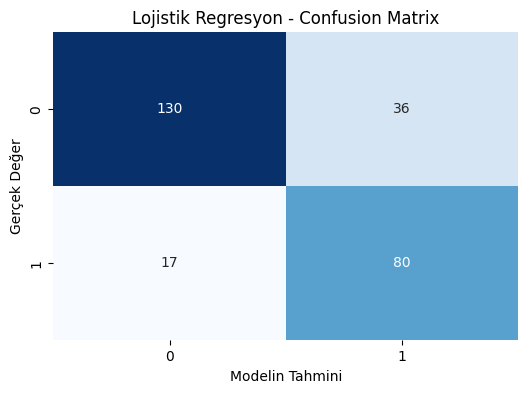

--- KARAR AĞACI (DECISION TREE) PERFORMANS RAPORU ---
Accuracy (Genel Doğruluk): 75.67%

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80       166
           1       0.66      0.70      0.68        97

    accuracy                           0.76       263
   macro avg       0.74      0.75      0.74       263
weighted avg       0.76      0.76      0.76       263



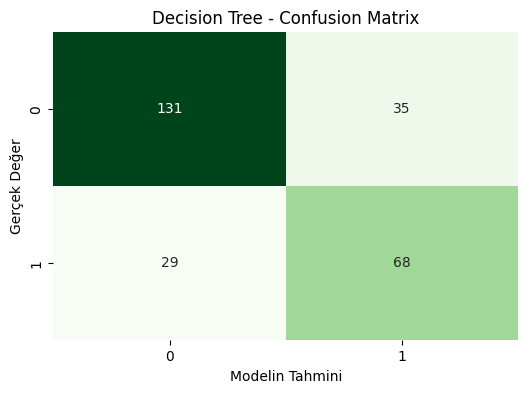

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# 1. Sadece sayısal sütunları seçerek X_train ve X_test'i arındıralım (İsim, bilet gibi metinler uçacak)
X_train_num = X_train.select_dtypes(include=['number'])
X_test_num = X_test.select_dtypes(include=['number'])

# 2. Lojistik Regresyon modelini kuralım
log_reg = LogisticRegression(random_state=42)

# 3. Modeli arındırılmış sayısal eğitim verisiyle eğitelim
log_reg.fit(X_train_num, y_train)

# 4. Test verisi üzerinden tahmin yapalım
y_pred_log = log_reg.predict(X_test_num)

# 5. Başarı Metriklerini Raporlayalım
print("--- LOJİSTİK REGRESYON PERFORMANS RAPORU ---")
print(f"Accuracy (Genel Doğruluk): {accuracy_score(y_test, y_pred_log) * 100:.2f}%\n")

print("Detaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_log))

# 6. Confusion Matrix Görselleştirme
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Lojistik Regresyon - Confusion Matrix")
plt.xlabel("Modelin Tahmini")
plt.ylabel("Gerçek Değer")
plt.show()

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# 1. Sadece sayısal sütunları seçtiğimizden emin olalım (önceki adımda yaptığımız gibi)
X_train_num = X_train.select_dtypes(include=['number'])
X_test_num = X_test.select_dtypes(include=['number'])

# 2. Decision Tree modelini kuralım (random_state=42 ile sonuçların sabit kalmasını sağlıyoruz)
decision_tree = DecisionTreeClassifier(random_state=42)

# 3. Modeli eğitelim (.fit)
decision_tree.fit(X_train_num, y_train)

# 4. Test verisi üzerinden tahmin yapalım (.predict)
y_pred_dt = decision_tree.predict(X_test_num)

# 5. Başarı Metriklerini Raporlayalım
print("--- KARAR AĞACI (DECISION TREE) PERFORMANS RAPORU ---")
print(f"Accuracy (Genel Doğruluk): {accuracy_score(y_test, y_pred_dt) * 100:.2f}%\n")

print("Detaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_dt))

# 6. Confusion Matrix Görselleştirme
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Modelin Tahmini")
plt.ylabel("Gerçek Değer")
plt.show()

--- RANDOM FOREST PERFORMANS RAPORU ---
Accuracy (Genel Doğruluk): 77.19%

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       166
           1       0.68      0.72      0.70        97

    accuracy                           0.77       263
   macro avg       0.76      0.76      0.76       263
weighted avg       0.78      0.77      0.77       263



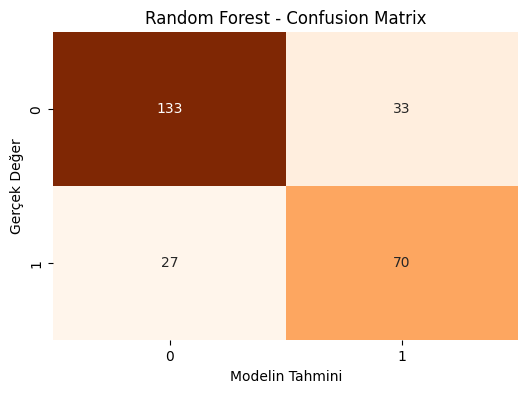

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sadece sayısal sütunları seçtiğimizden emin olalım
X_train_num = X_train.select_dtypes(include=['number'])
X_test_num = X_test.select_dtypes(include=['number'])

# 2. Random Forest modelini kuralım (n_estimators=100 demek, arkada 100 tane farklı karar ağacı çalışacak demektir)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Modeli eğitelim (.fit)
random_forest.fit(X_train_num, y_train)

# 4. Test verisi üzerinden tahmin yapalım (.predict)
y_pred_rf = random_forest.predict(X_test_num)

# 5. Başarı Metriklerini Raporlayalım
print("--- RANDOM FOREST PERFORMANS RAPORU ---")
print(f"Accuracy (Genel Doğruluk): {accuracy_score(y_test, y_pred_rf) * 100:.2f}%\n")

print("Detaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_rf))

# 6. Confusion Matrix Görselleştirme
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Modelin Tahmini")
plt.ylabel("Gerçek Değer")
plt.show()

In [56]:
print("---Verinin ilk 5 satırı---")
display(df.head())
print("---Verinin son 5 satırı ")
display(df.tail())

print("--Sutunlardaki null sayıları")
display(df.isnull().sum())



---Verinin ilk 5 satırı---


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_Encoded,Embarked_Q,Embarked_S,FamilySize,IsAlone,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,1,0,7.250,0,0,1,2,0,0,1,0,0
1,1,1,38.0,1,0,66.300,1,0,0,2,0,0,0,1,0
2,1,3,26.0,0,0,7.925,1,0,1,1,1,1,0,0,0
3,1,1,35.0,1,0,53.100,1,0,1,2,0,0,0,1,0
4,0,3,35.0,0,0,8.050,0,0,1,1,1,0,1,0,0


---Verinin son 5 satırı 


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_Encoded,Embarked_Q,Embarked_S,FamilySize,IsAlone,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
886,0,2,27.0,0,0,13.00,0,0,1,1,1,0,0,0,1
887,1,1,19.0,0,0,30.00,1,0,1,1,1,1,0,0,0
888,0,3,28.0,1,2,23.45,1,0,1,4,0,1,0,0,0
889,1,1,26.0,0,0,30.00,0,0,0,1,1,0,1,0,0
890,0,3,32.0,0,0,7.75,0,1,0,1,1,0,1,0,0


--Sutunlardaki null sayıları


,0
Survived,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0
Sex_Encoded,0
Embarked_Q,0
Embarked_S,0
FamilySize,0


In [46]:
eksik_degerler = df.isnull().sum()
print(eksik_degerler)

Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
Sex_Encoded    0
Embarked_Q     0
Embarked_S     0
FamilySize     0
IsAlone        0
Title_Miss     0
Title_Mr       0
Title_Mrs      0
Title_Rare     0
dtype: int64


--- ÖZELLİK ÖNEM DÜZEYLERİ ---
        Feature  Importance
1           Age    0.231259
4          Fare    0.219128
11     Title_Mr    0.129932
0        Pclass    0.109607
5   Sex_Encoded    0.102959
8    FamilySize    0.042167
12    Title_Mrs    0.034204
2         SibSp    0.033345
10   Title_Miss    0.031556
7    Embarked_S    0.022605
3         Parch    0.018775
6    Embarked_Q    0.010094
9       IsAlone    0.009168
13   Title_Rare    0.005201


/tmp/ipykernel_4468/1854176396.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


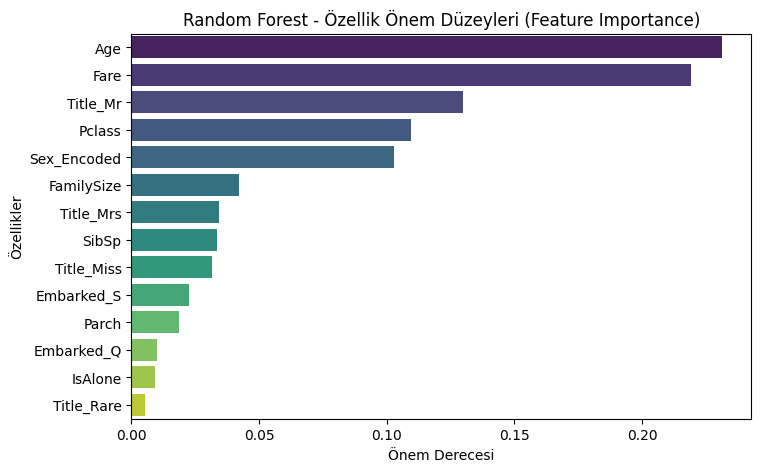

In [57]:

# 1. Random Forest modelinden özellik önem düzeylerini alalım
importances = random_forest.feature_importances_

# 2. Sütun isimleriyle eşleştirip DataFrame oluşturalım
feature_importance_df = pd.DataFrame({
    'Feature': X_train_num.columns,
    'Importance': importances
})

# 3. Büyükten küçüğe sıralayalım
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("--- ÖZELLİK ÖNEM DÜZEYLERİ ---")
print(feature_importance_df)

# 5. Görselleştirelim
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title("Random Forest - Özellik Önem Düzeyleri (Feature Importance)")
plt.xlabel("Önem Derecesi")
plt.ylabel("Özellikler")
plt.show()